Part 8: Deep Neural Network Comparison (YOLO)
Compares our background subtraction detector against YOLO pretrained on COCO.

In [13]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from ultralytics import YOLO
import time

frames_path = Path("../frames/View_001/")
n_frames = 795
confidence_threshold = 0.5

In [14]:
def detect_pedestrians_yolo(image, conf_threshold=0.5):
    """
    Run YOLO detection on an image and return pedestrian bounding boxes.

    Returns:
        List of bounding boxes: [x1, y1, x2, y2, confidence]
    """
    results = model(image, verbose=False)  # verbose=False to avoid printing

    detections = []
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                cls_id = int(box.cls[0])
                if cls_id == PERSON_CLASS_ID:
                    conf = float(box.conf[0])
                    if conf >= conf_threshold:
                        x1, y1, x2, y2 = box.xyxy[0].tolist()
                        detections.append([x1, y1, x2, y2, conf])
    return detections

print("Loading YOLO26n pretrained model...")
model = YOLO("yolo26n.pt") # Pretrained on COCO
PERSON_CLASS_ID = 0
print("Model loaded successfully!")

Loading YOLO26n pretrained model...
Model loaded successfully!


In [15]:
yolo_detections_by_frame = {}
frame_indices = []

print(f"Processing frames with YOLO...")
start_time = time.time()

for f in range(0, n_frames):
    frame_file = frames_path / f"frame_{f:04d}.jpg"
    if not frame_file.exists():
        continue

    img = cv2.imread(str(frame_file))
    if img is None:
        continue

    detections = detect_pedestrians_yolo(img, confidence_threshold)
    yolo_detections_by_frame[f] = detections
    frame_indices.append(f)

    if len(frame_indices) % 50 == 0:
        print(f"  Processed {len(frame_indices)} frames...")

elapsed = time.time() - start_time
print(f"Completed! Processed {len(frame_indices)} frames in {elapsed:.1f} seconds")
print(f"Average {elapsed/len(frame_indices):.2f} seconds per frame")

Processing frames with YOLO...
  Processed 50 frames...
  Processed 100 frames...
  Processed 150 frames...
  Processed 200 frames...
  Processed 250 frames...
  Processed 300 frames...
  Processed 350 frames...
  Processed 400 frames...
  Processed 450 frames...
  Processed 500 frames...
  Processed 550 frames...
  Processed 600 frames...
  Processed 650 frames...
  Processed 700 frames...
  Processed 750 frames...
Completed! Processed 795 frames in 29.0 seconds
Average 0.04 seconds per frame


In [16]:
import scipy.io as sio
import os

# Our detections from Part 2 (saved as our_detections.txt)
det_file = Path("../data/our_detections.txt")
gt_file = Path("../data/gt/gt.txt")

our_detections_by_frame = {}
gt_by_frame = {}

if os.path.exists(det_file):
    # Format: [frame, id, left, top, width, height, conf, x, y, z]
    our_data = np.loadtxt(det_file, delimiter=',')

    for row in our_data:
        f = int(row[0])
        left, top, width, height = row[2], row[3], row[4], row[5]
        x1, y1, x2, y2 = left, top, left + width, top + height
        conf = row[6]
        
        if f not in our_detections_by_frame:
            our_detections_by_frame[f] = []
        our_detections_by_frame[f].append([x1, y1, x2, y2, conf])

    print(f"Loaded our detector results from {det_file}")
    print(f"  Total detections: {len(our_data)}")
    print(f"  Frames with detections: {len(our_detections_by_frame)}")
else:
    print(f"Warning: {det_file} not found. Run Part 2 first.")
    our_detections_by_frame = {}
print()

if os.path.exists(gt_file):
    gt_data = np.loadtxt(gt_file, delimiter=',')
    for row in gt_data:
        f = int(row[0])
        left, top, width, height = row[2], row[3], row[4], row[5]
        x1, y1, x2, y2 = left, top, left + width, top + height
        person_id = int(row[1])

        if f not in gt_by_frame:
            gt_by_frame[f] = []
        gt_by_frame[f].append([x1, y1, x2, y2, person_id])

    print(f"Loaded ground truth from {gt_file}")
    print(f"  Total annotations: {len(gt_data)}")
    print(f"  Frames with GT: {len(gt_by_frame)}")
else:
    print(f"Error: {gt_file} not found")
    gt_by_frame = {}

common_frames = set(yolo_detections_by_frame.keys()) & set(our_detections_by_frame.keys()) & set(gt_by_frame.keys())
common_frames = sorted(common_frames)

gt_counts = [len(gt_by_frame[f]) for f in common_frames]
yolo_counts = [len(yolo_detections_by_frame[f]) for f in common_frames]
our_counts = [len(our_detections_by_frame[f]) for f in common_frames]

Loaded our detector results from ../data/our_detections.txt
  Total detections: 3744
  Frames with detections: 795

Loaded ground truth from ../data/gt/gt.txt
  Total annotations: 4650
  Frames with GT: 795


IoU WITH GROUND TRUTH
Total ground truth objects: 4643

YOLO:
  True Positives: 3780 (81.4%)
  False Negatives: 863 (18.6%)
  Frames with IoU > 0.5: 793 (99.9%)
  Mean best IoU per frame: 0.841
  Median IoU: 0.728

Our Detector:
  True Positives: 2944 (63.4%)
  False Negatives: 1699 (36.6%)
  Frames with IoU > 0.5: 776 (97.7%)
  Median best IoU per frame: 0.800
  Median IoU: 0.717


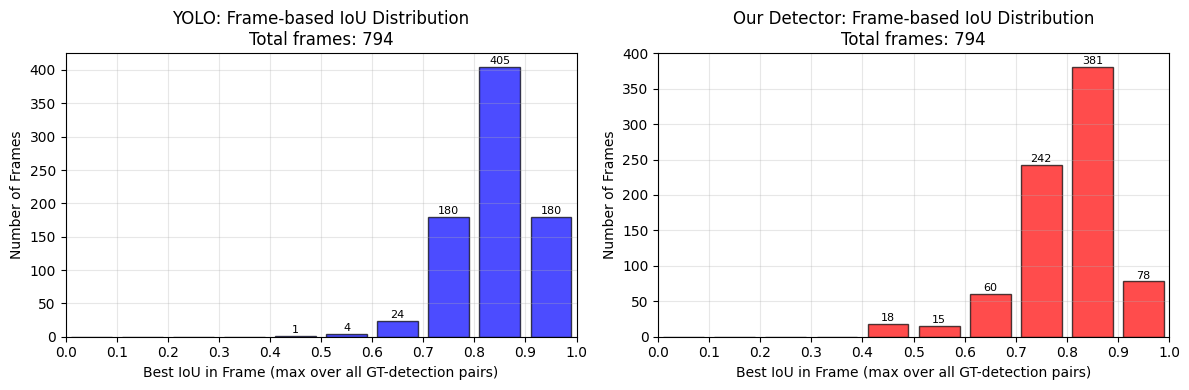

In [17]:
def compute_iou(box1, box2):
    """Compute IoU between two boxes [x1,y1,x2,y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0

def compute_frame_best_iou(gt_boxes, det_boxes):
    """
    For a single frame, compute the best IoU achievable.
    Returns the maximum IoU over all GT-detection pairs.
    """
    if len(gt_boxes) == 0 or len(det_boxes) == 0:
        return 0.0
    
    best_iou = 0.0
    for gt in gt_boxes:
        for det in det_boxes:
            iou_val = compute_iou(gt[:4], det[:4])
            if iou_val > best_iou:
                best_iou = iou_val
    
    return best_iou

def match_detections_to_gt(gt_boxes, det_boxes, iou_threshold=0.5):
    n_gt = len(gt_boxes)
    n_det = len(det_boxes)

    if n_gt == 0 or n_det == 0:
        return [], []

    iou_mat = np.zeros((n_gt, n_det))
    for i in range(n_gt):
        for j in range(n_det):
            iou_mat[i, j] = compute_iou(gt_boxes[i][:4], det_boxes[j][:4])

    matched_gt = np.zeros(n_gt, dtype=bool)
    matched_det = np.zeros(n_det, dtype=bool)
    iou_scores = []

    pairs = []
    for i in range(n_gt):
        for j in range(n_det):
            if iou_mat[i, j] >= iou_threshold:
                pairs.append((iou_mat[i, j], i, j))
    
    pairs.sort(reverse=True)
    
    for iou_val, i, j in pairs:
        if not matched_gt[i] and not matched_det[j]:
            matched_gt[i] = True
            matched_det[j] = True
            iou_scores.append(iou_val)
    
    return iou_scores, matched_gt, matched_det

# Evaluate both methods against ground truth – frame-based
yolo_frame_ious = []
our_frame_ious = []
yolo_iou_scores = []
our_iou_scores = []
yolo_tp = 0
our_tp = 0
total_gt = 0

for f in common_frames:
    gt_boxes = gt_by_frame[f]
    yolo_boxes = yolo_detections_by_frame[f]
    our_boxes = our_detections_by_frame[f]

    total_gt += len(gt_boxes)
    
    # IoU for YOLO
    yolo_best = compute_frame_best_iou(gt_boxes, yolo_boxes)
    yolo_frame_ious.append(yolo_best)

    yolo_ious, yolo_matched_gt, _ = match_detections_to_gt(gt_boxes, yolo_boxes)
    yolo_iou_scores.extend(yolo_ious)
    yolo_tp += len(yolo_ious)
    
    # IoU for our detector
    our_best = compute_frame_best_iou(gt_boxes, our_boxes)
    our_frame_ious.append(our_best)

    our_ious, our_matched_gt, _ = match_detections_to_gt(gt_boxes, our_boxes)
    our_iou_scores.extend(our_ious)
    our_tp += len(our_ious)

yolo_frame_ious = np.array(yolo_frame_ious)
our_frame_ious = np.array(our_frame_ious)

# Calculate statistics
print("=" * 60)
print("IoU WITH GROUND TRUTH")
print("=" * 60)
print(f"Total ground truth objects: {total_gt}")
print(f"\nYOLO:")
print(f"  True Positives: {yolo_tp} ({100*yolo_tp/total_gt:.1f}%)")
print(f"  False Negatives: {total_gt - yolo_tp} ({100*(total_gt - yolo_tp)/total_gt:.1f}%)")
print(f"  Frames with IoU > 0.5: {np.sum(yolo_frame_ious > 0.5)} ({100*np.mean(yolo_frame_ious > 0.5):.1f}%)")
print(f"  Mean best IoU per frame: {np.mean(yolo_frame_ious):.3f}")
print(f"  Median IoU: {np.median(yolo_iou_scores):.3f}")
print(f"\nOur Detector:")
print(f"  True Positives: {our_tp} ({100*our_tp/total_gt:.1f}%)")
print(f"  False Negatives: {total_gt - our_tp} ({100*(total_gt - our_tp)/total_gt:.1f}%)")
print(f"  Frames with IoU > 0.5: {np.sum(our_frame_ious > 0.5)} ({100*np.mean(our_frame_ious > 0.5):.1f}%)")
print(f"  Median best IoU per frame: {np.mean(our_frame_ious):.3f}")
print(f"  Median IoU: {np.median(our_iou_scores):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.arange(0, 1.1, 0.1)

# YOLO histogram
counts_yolo, edges = np.histogram(yolo_frame_ious, bins=bins)
centers = edges[:-1] + 0.05
axes[0].bar(centers, counts_yolo, width=0.08, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Best IoU in Frame (max over all GT-detection pairs)')
axes[0].set_ylabel('Number of Frames')
axes[0].set_title(f'YOLO: Frame-based IoU Distribution\nTotal frames: {len(common_frames)}')
axes[0].set_xlim([0, 1])
axes[0].set_xticks(np.arange(0, 1.1, 0.1))
axes[0].grid(True, alpha=0.3)

for i, count in enumerate(counts_yolo):
    if count > 0:
        axes[0].text(centers[i], count + 1, str(count), 
                    ha='center', va='bottom', fontsize=8)

# Our detector histogram
counts_our, _ = np.histogram(our_frame_ious, bins=bins)
axes[1].bar(centers, counts_our, width=0.08, color='red', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Best IoU in Frame (max over all GT-detection pairs)')
axes[1].set_ylabel('Number of Frames')
axes[1].set_title(f'Our Detector: Frame-based IoU Distribution\nTotal frames: {len(common_frames)}')
axes[1].set_xlim([0, 1])
axes[1].set_xticks(np.arange(0, 1.1, 0.1))
axes[1].grid(True, alpha=0.3)

for i, count in enumerate(counts_our):
    if count > 0:
        axes[1].text(centers[i], count + 1, str(count), 
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

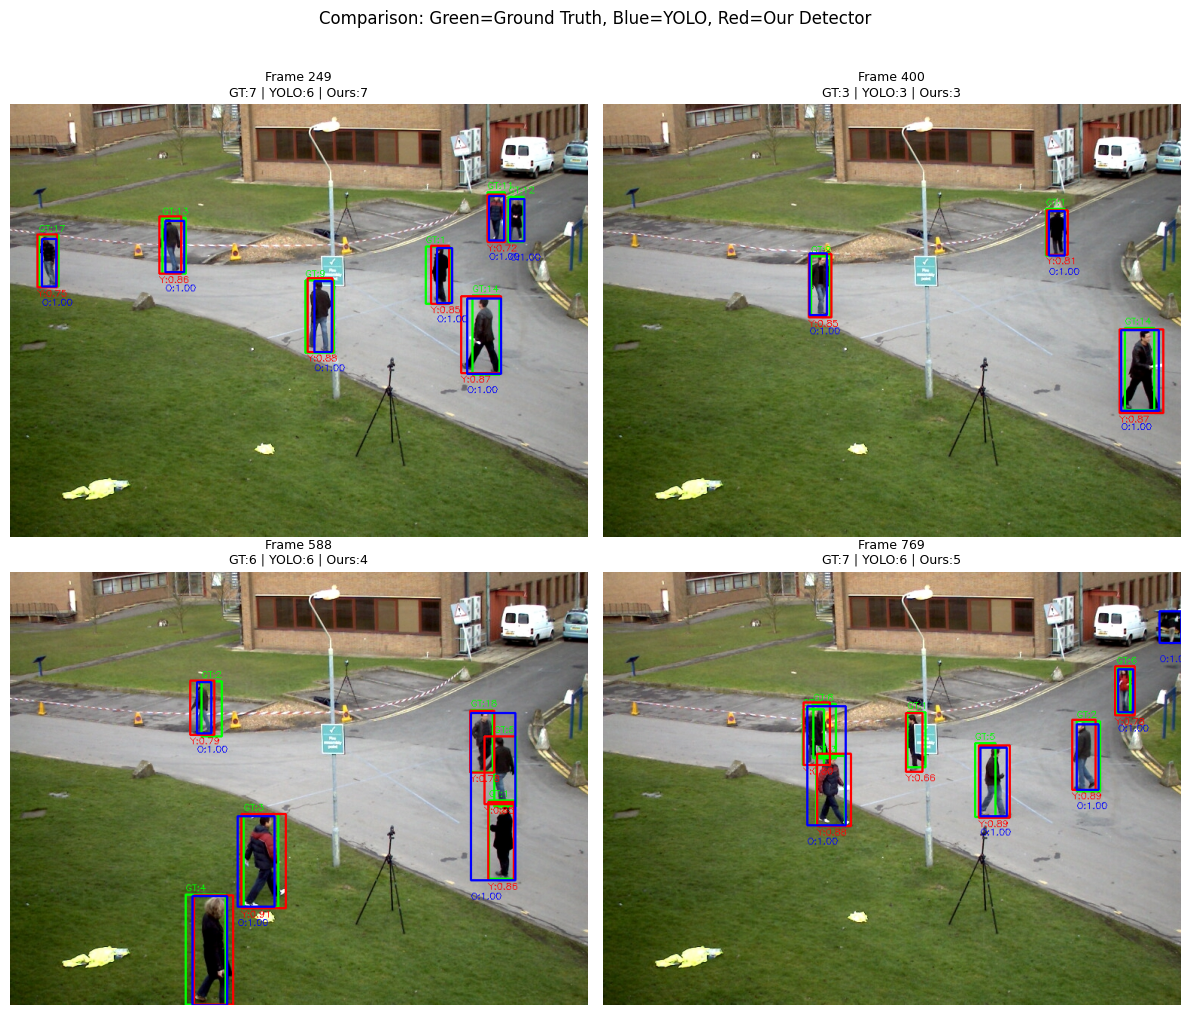

In [30]:
def draw_all_detections(image, gt_boxes, yolo_boxes, our_boxes):
    """Draw all three on the same image with different colors"""
    img_copy = image.copy()
    
    # Draw Ground Truth (green)
    for i, gt in enumerate(gt_boxes):
        x1, y1, x2, y2, pid = gt
        cv2.rectangle(img_copy, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        cv2.putText(img_copy, f"GT:{pid}", (int(x1), int(y1)-5), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
    
    # Draw YOLO detections (blue)
    for i, yolo in enumerate(yolo_boxes):
        x1, y1, x2, y2, conf = yolo
        cv2.rectangle(img_copy, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
        cv2.putText(img_copy, f"Y:{conf:.2f}", (int(x1), int(y2)+12), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
    
    # Draw Our detections (red)
    for i, our in enumerate(our_boxes):
        x1, y1, x2, y2, conf = our
        cv2.rectangle(img_copy, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
        cv2.putText(img_copy, f"O:{conf:.2f}", (int(x1), int(y2)+25), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
    
    return img_copy

# Select frames with various scenarios
frames_to_show = [249, 400, 588, 769]
for f in common_frames:
    if len(gt_by_frame[f]) > 0 and len(yolo_detections_by_frame[f]) > 0:
        frames_to_show.append(f)
    if len(frames_to_show) >= 6:
        break

# Ensure we have good spread
frames_to_show = frames_to_show[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, f in enumerate(frames_to_show):
    # Load original frame
    img_path = frames_path / f"frame_{f:04d}.jpg"
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Get all annotations
    gt_boxes = gt_by_frame.get(f, [])
    yolo_boxes = yolo_detections_by_frame.get(f, [])
    our_boxes = our_detections_by_frame.get(f, [])
    
    # Draw everything
    img_with_all = draw_all_detections(img_rgb, gt_boxes, yolo_boxes, our_boxes)
    
    axes[idx].imshow(img_with_all)
    axes[idx].set_title(f"Frame {f}\nGT:{len(gt_boxes)} | YOLO:{len(yolo_boxes)} | Ours:{len(our_boxes)}", fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Comparison: Green=Ground Truth, Blue=YOLO, Red=Our Detector', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
